Menggunakan device: cpu
Jumlah data training: 60000
Jumlah data testing : 10000

=== Training dengan lr=0.001, batch_size=64, optimizer=Adam ===
Epoch [1/5] - Loss: 0.2539 - Test Accuracy: 95.52%
Epoch [2/5] - Loss: 0.1076 - Test Accuracy: 97.31%
Epoch [3/5] - Loss: 0.0744 - Test Accuracy: 97.73%
Epoch [4/5] - Loss: 0.0582 - Test Accuracy: 97.35%
Epoch [5/5] - Loss: 0.0456 - Test Accuracy: 97.79%
Masa training: 81.31 saat

=== Training dengan lr=0.01, batch_size=64, optimizer=Adam ===
Epoch [1/5] - Loss: 0.3029 - Test Accuracy: 93.51%
Epoch [2/5] - Loss: 0.2050 - Test Accuracy: 94.17%
Epoch [3/5] - Loss: 0.1837 - Test Accuracy: 95.21%
Epoch [4/5] - Loss: 0.1684 - Test Accuracy: 95.03%
Epoch [5/5] - Loss: 0.1649 - Test Accuracy: 95.51%
Masa training: 82.67 saat

=== RINGKASAN PERBANDINGAN HYPERPARAMETER TUNING ===
LR=0.001 -> Accuracy akhir: 97.79%
LR=0.01  -> Accuracy akhir: 95.51%


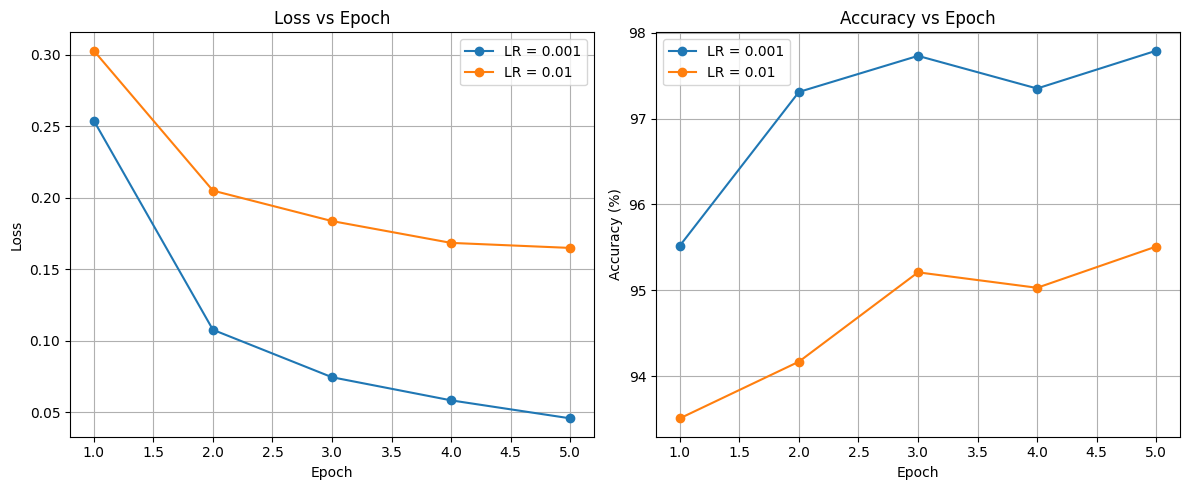


Graf telah disimpan sebagai 'hasil_perbandingan_ann_mnist.png'
=== TRAINING SELESAI ===


In [4]:
"""
=====================================================================
DKB 3263 - KECERDASAN BUATAN UNTUK COMPUTER VISION
TUGASAN AMALI: Python Programming dan Artificial Neural Network (ANN)

Objektif:
Membangunkan satu Artificial Neural Network (ANN) menggunakan PyTorch
untuk mengklasifikasikan dataset MNIST (digit 0-9).

Struktur mengikut arahan tugasan (6.0 - 6.3):
- 6.1: ANN mengandungi Input layer, 1 Hidden layer, Output layer,
       fungsi aktivasi, fungsi loss (CrossEntropyLoss), optimizer.
- 6.2: Hyperparameter tuning asas (contoh: learning rate) dan
       perbandingan hasil.
- 6.3: Plot graf loss vs epoch dan accuracy vs epoch.
=====================================================================
"""

# =====================================================================
# 7.2.1 - IMPORT & SETUP LIBRARY
# =====================================================================
import torch                                   # Library utama PyTorch
import torch.nn as nn                          # Modul untuk membina neural network
import torch.optim as optim                    # Modul untuk optimizer (SGD, Adam, dll.)
import torchvision                             # Library untuk dataset yang digunakan untuk training model & transformasi imej
import torchvision.transforms as transforms    # Untuk preprocessing dataset (normalize, tensor, dll.)
from torch.utils.data import DataLoader        # Untuk load data secara batch
import matplotlib.pyplot as plt                # Untuk plot graf loss/accuracy vs epoch
import time                                    # Untuk mengira masa training (opsyenal, rekod prestasi)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Set 'device' - guna GPU (CUDA) jika ada, jika tidak guna CPU
print(f"Menggunakan device: {device}")

torch.manual_seed(42) # Set seed supaya keputusan boleh diulang (reproducibility)

# =====================================================================
# 7.2.2 - LOAD & PREPROCESS DATASET MNIST
# =====================================================================
# Transformasi: tukar imej kepada Tensor + normalize nilai pixel
# (0.1307, 0.3081) adalah nilai mean & std piawai untuk dataset MNIST
transform = transforms.Compose([
    transforms.ToTensor(),                       # Tukar imej PIL/array kepada Tensor PyTorch
    transforms.Normalize((0.1307,), (0.3081,))   # Normalize supaya model lebih stabil & cepat converge
])

# Muat turun (download) dataset MNIST menggunakan torchvision - training set dan testing set
train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

print(f"Jumlah data training: {len(train_dataset)}")
print(f"Jumlah data testing : {len(test_dataset)}")


# =====================================================================
# 7.2.3 - BINA MODEL ANN
# =====================================================================
class ANN_MNIST(nn.Module): # Permulaan membina Model ANN

    def __init__(self, input_size=28 * 28, hidden_size=128, output_size=10):
        super(ANN_MNIST, self).__init__()

        self.flatten = nn.Flatten()         # Ratakan imej 28x28 pixel menjadi satu vektor sepanjang 784, (Diperlukan kerana imej MNIST berbentuk 2D, tetapi Input Layer ANN memerlukan input dalam bentuk vektor 1D)

        # =========================== INPUT LAYER ===========================
        self.input_layer = nn.Linear(input_size, hidden_size)        # Menerima 784 nilai pixel (28x28) sebagai neuron input dan menghantarnya ke Hidden Layer

        # ------------------------- FUNGSI AKTIVASI --------------------------

        self.activation1 = nn.ReLU()        # ReLU digunakan selepas Input Layer untuk memperkenalkan sifat non-linear kepada rangkaian

        # =========================== HIDDEN LAYER ===========================
        # 1 lapisan tersembunyi (hidden layer) yang memproses maklumat
        # daripada Input Layer sebelum dihantar ke Output Layer
        self.hidden_layer = nn.Linear(hidden_size, hidden_size)

        # ------------------------- FUNGSI AKTIVASI --------------------------
        self.activation2 = nn.ReLU()         # ReLU digunakan selepas Hidden Layer

        # =========================== OUTPUT LAYER ===========================
        self.output_layer = nn.Linear(hidden_size, output_size)           # Menghasilkan 10 output (mewakili kelas digit 0 hingga 9)

    def forward(self, x):
        """
        Aliran data (forward pass) mengikut susunan:
        Input Layer -> Aktivasi -> Hidden Layer -> Aktivasi -> Output Layer
        """
        x = self.flatten(x)          # (batch, 1, 28, 28) -> (batch, 784)

        x = self.input_layer(x)      # ===== INPUT LAYER =====
        x = self.activation1(x)      # Fungsi aktivasi ReLU

        x = self.hidden_layer(x)     # ===== HIDDEN LAYER =====
        x = self.activation2(x)      # Fungsi aktivasi ReLU

        x = self.output_layer(x)     # ===== OUTPUT LAYER ===== (logits, belum softmax)
        return x


# =====================================================================
# FUNGSI TRAINING & EVALUATION (digunakan semula untuk hyperparameter tuning)
# =====================================================================
def train_and_evaluate(learning_rate, batch_size, epochs=5, optimizer_name="Adam"):

    # DataLoader - memuatkan data secara batch mengikut 'batch_size' yang diberi
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    # Bina model baru setiap kali fungsi dipanggil (supaya perbandingan adil / fair)
    model = ANN_MNIST().to(device)

    # ---------------- LOSS FUNCTION & OPTIMIZER ----------------
    criterion = nn.CrossEntropyLoss()   # Fungsi loss untuk masalah klasifikasi multi-kelas

    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    else:
        optimizer = optim.SGD(model.parameters(), lr=learning_rate)

    # Senarai untuk simpan sejarah loss & accuracy setiap epoch (untuk plot graf nanti)
    loss_history = []
    accuracy_history = []

    print(f"\n=== Training dengan lr={learning_rate}, batch_size={batch_size}, optimizer={optimizer_name} ===")
    start_time = time.time()

    # ---------------- TRAINING LOOP ----------------
    for epoch in range(epochs):
        model.train()               # Set model ke mode training
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()               # Reset gradient sebelum backward pass
            outputs = model(images)             # Forward pass - dapatkan prediksi
            loss = criterion(outputs, labels)   # Kira loss antara prediksi & label sebenar

            loss.backward()                     # Backward pass - kira gradient
            optimizer.step()                    # Update parameter/weight model

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)
        loss_history.append(avg_loss)

        # ---------------- VALIDATION/TESTING ACCURACY ----------------
        model.eval()          # Set model ke mode evaluation (tiada dropout/gradient update)
        correct = 0
        total = 0

        with torch.no_grad():           # Tidak perlu kira gradient semasa testing
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)   # Ambil kelas dengan skor tertinggi
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        accuracy_history.append(accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f} - Test Accuracy: {accuracy:.2f}%")

    elapsed = time.time() - start_time
    print(f"Masa training: {elapsed:.2f} saat")

    return loss_history, accuracy_history


# =====================================================================
# 6.2 - HYPERPARAMETER TUNING & PERBANDINGAN HASIL
# =====================================================================
# Kita bandingkan dua nilai learning rate yang berbeza (contoh parameter
# yang diubah), dengan batch_size dan epoch yang sama untuk kedua-dua ujian.

EPOCHS = 5
BATCH_SIZE = 64

# Percubaan 1: Learning rate = 0.001 (lebih perlahan, lebih stabil)
loss_1, acc_1 = train_and_evaluate(learning_rate=0.001, batch_size=BATCH_SIZE, epochs=EPOCHS)

# Percubaan 2: Learning rate = 0.01 (lebih cepat, tetapi berisiko tidak stabil)
loss_2, acc_2 = train_and_evaluate(learning_rate=0.01, batch_size=BATCH_SIZE, epochs=EPOCHS)

# Cetak ringkasan perbandingan akhir
print("\n=== RINGKASAN PERBANDINGAN HYPERPARAMETER TUNING ===")
print(f"LR=0.001 -> Accuracy akhir: {acc_1[-1]:.2f}%")
print(f"LR=0.01  -> Accuracy akhir: {acc_2[-1]:.2f}%")


# =====================================================================
# 6.3 - PLOT GRAF LOSS VS EPOCH & ACCURACY VS EPOCH
# =====================================================================
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

# ----- Graf 1: Loss vs Epoch -----
plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss_1, marker='o', label="LR = 0.001")
plt.plot(epochs_range, loss_2, marker='o', label="LR = 0.01")
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# ----- Graf 2: Accuracy vs Epoch -----
plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc_1, marker='o', label="LR = 0.001")
plt.plot(epochs_range, acc_2, marker='o', label="LR = 0.01")
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("hasil_perbandingan_ann_mnist.png")   # Simpan graf sebagai fail imej
plt.show()

print("\nGraf telah disimpan sebagai 'hasil_perbandingan_ann_mnist.png'")
print("=== TRAINING SELESAI ===")